In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import scipy
from scipy.stats import pearsonr

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay)

import json
import joblib

In [3]:
#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
#Path for the Development Data
if not os.path.exists("../data/development_data.csv"):
    print("Data Path does not exist. Expected in `../data/development_data.csv`")
    exit

dev_data = pd.read_csv(os.path.join("../data/development_data.csv"))

#Path for the Evaluation Data
if not os.path.exists("../data/evaluation_data.csv"):
    print("Data Path does not exist. Expected in `../data/evaluation_data.csv`")
    exit

eva_data = pd.read_csv(os.path.join("../data/evaluation_data.csv"))

In [5]:
#This is from Task1. I didn't saved the initial sets after spliting of dataset (only after the preprocessing pipeline) and I need them to fit the preprocessor
#Clean the development data before spliting
#First remove the sample_id column (no information here)
dev_df = dev_data.copy()
dev_df = dev_df.drop(columns=['sample_id'])

#Map the categorical values 
map_sex_labels = {'M': 0, 'F':1}
dev_df['sex'] = dev_df['sex'].map(map_sex_labels).astype('category')

map_ethnicity_labels = {'Caucasian - European': 0, 'Hispanic - Mexican': 1}
dev_df['ethnicity'] =dev_df['ethnicity'].map(map_ethnicity_labels).astype('category')

#Split the data using the split_data function
#From the above analysis, I can see that there are 12 age values that appear only once in the dataset
#So, I have to create age groups and then split the data. I decided to create 4 different age groups

#Import function
from src.functions import split_data

X_train, X_val, y_train, y_val = split_data(dev_df, target='age')

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 364
Validation set size: 92


In [6]:
#Clean the evaluation data before spliting
#First remove the sample_id column (no information here)
eva_df = eva_data.copy()
eva_df = eva_df.drop(columns=['sample_id'])

#Seperate the target variable age from the evaluation dataset
y_eval = eva_df['age']
X_eval_raw = eva_df.drop(columns=['age'])

#Map the categorical values 
X_eval_raw['sex'] = X_eval_raw['sex'].map(map_sex_labels).astype('category')
X_eval_raw['ethnicity'] =X_eval_raw['ethnicity'].map(map_ethnicity_labels).astype('category')

print(f"Evaluation set size: {X_eval_raw.shape[0]}")

Evaluation set size: 100


In [7]:
#Run again the fit of the preprocessor on the training set and then transform the evaluation set
#Define the numerical_features and the categorical_features
categorical_features = ['sex', 'ethnicity']
numerical_features = [columns for columns in X_train.columns if columns not in categorical_features]

#Import the preprocessing_pipeline fron the src/functions.py 
from src.functions import preprocessing_pipeline

#Apply the preprocessor
preprocessor = preprocessing_pipeline(numerical_features, categorical_features)

#Fit on training set and transform the evaluation set
#Fit and transform training set (learns the median from the training set)
X_train_proc = preprocessor.fit_transform(X_train)

#Transform evaluation set (No fitting - Data leakage)
X_eval_proc = preprocessor.transform(X_eval_raw)

#Column names after preprocessor
prep_names = preprocessor.named_transformers_['categorical'].get_feature_names_out(categorical_features)
columns_final = list(numerical_features) + list(prep_names)

X_eval_final = pd.DataFrame(X_eval_proc, columns=columns_final, index=X_eval_raw.index)

In [ ]:
#Import the selected-feature set from task 3. mRMR selected feature set for k=50
file_path = '../data/selected_features/selected_features.json'

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        loaded_data = json.load(f)
    
    # Extract the list with the features
    selected_mrmr_features = loaded_data["mrmr_features"]
    
    print(f"Successfully loaded mRMR selected features list")
    
else:
    print("Error: JSON file not found. Check your directory path!")

Successfully loaded mRMR selected features list


In [9]:
#Filter the evaluation set for the 50 mRMR selected features
X_eval_filt = X_eval_final[selected_mrmr_features]

#Save the ready evaluation set
#Create a folder inside the data folder
os.makedirs('../data/evaluation', exist_ok=True)

#Save the matrices for the training set
X_eval_filt.to_pickle('../data/evaluation/X_eval_filt.pkl')
y_eval.to_pickle('../data/evaluation/y_val.pkl')

print(f"Evaluation set ready and saved. Evaluation set shape: {X_eval_filt.shape}")

Evaluation set ready and saved. Evaluation set shape: (100, 50)


In [7]:
#After the preprocessig of the evaluation set the same way used for the development set, we can proceed with making predictions using the tuned models.
#Import the tuned models
final_elasticnet = joblib.load('../models/Tuned_estimators/tuned_elastinet.joblib')
final_svr = joblib.load('../models/Tuned_estimators/tuned_svr.joblib')
final_bayesianridge = joblib.load('../models/Tuned_estimators/tuned_bayesianridge.joblib')

print(f"Tuned models uploaded successfully")

Tuned models uploaded successfully


In [12]:
final_elasticnet_pred = final_elasticnet.predict(X_eval_filt)
final_svr_pred = final_svr.predict(X_eval_filt)
final_bayesianridge_pred = final_bayesianridge.predict(X_eval_filt)

#Bootstrap

from src.functions import bootstrap_apply

#Dictionary with the 3 different models
final_models_pred = {
    'ElasticNet' : final_elasticnet_pred,
    'SVR' : final_svr_pred,
    'BayesianRidge' : final_bayesianridge_pred}

#Initialize an empty dictionary, in which the bootstrap metrics will be saved
final_models_stats = {}

for model_name, y_pred in final_models_pred.items():
    #Perform the bootstrap function
    bootstrap_df = bootstrap_apply(y_pred, y_eval, n_resamples=1000, seed=42)
    #Store the bootstraq results in the dictionary
    final_models_stats[model_name] = bootstrap_df

    print(f"Bootstrap pipeline completed for the model: {model_name}")


Bootstrap pipeline completed for the model: ElasticNet
Bootstrap pipeline completed for the model: SVR
Bootstrap pipeline completed for the model: BayesianRidge


In [ ]:
#Save Metrics
# Define the metrics
metrics = ['RMSE', 'R2', 'MAE', 'Pearson_r']
rows = []

# Loop through each model 
for metric in metrics:
    row_mean = {'Metric': f'{metric} Mean'}
    row_std  = {'Metric': f'{metric} Std'}
    row_ci   = {'Metric': f'95% CI ({metric})'}
    
    for model_name in final_models_stats.keys():
        stats = final_models_stats[model_name][metric]
        
        # Calculate values
        mean_val = stats.mean()
        std_val  = stats.std()
        ci_low   = stats.quantile(0.025)
        ci_high  = stats.quantile(0.975)
        
        # Assign to rows
        row_mean[model_name] = round(mean_val, 2)
        row_std[model_name]  = round(std_val, 2)
        row_ci[model_name]   = f"[{ci_low:.2f}, {ci_high:.2f}]"
    
    rows.extend([row_mean, row_std, row_ci])

# Create the final DataFrame
table_statistics = pd.DataFrame(rows)

# Save the table
os.makedirs('../data/evaluation', exist_ok=True)
table_statistics.to_csv('../data/evaluation/task4_evaluation_metrics.csv', index=False)

print("Final evaluation table saved successfully.")
print(table_statistics)

Final evaluation table saved successfully.
                Metric    ElasticNet           SVR BayesianRidge
0            RMSE Mean          5.33          5.55          5.39
1             RMSE Std           0.5          0.53          0.51
2        95% CI (RMSE)  [4.43, 6.33]  [4.54, 6.63]  [4.46, 6.43]
3              R2 Mean          0.86          0.84          0.85
4               R2 Std          0.04          0.04          0.04
5          95% CI (R2)  [0.77, 0.92]  [0.75, 0.91]  [0.77, 0.91]
6             MAE Mean          4.08          4.19          4.06
7              MAE Std          0.34          0.36          0.35
8         95% CI (MAE)  [3.48, 4.76]  [3.54, 4.94]  [3.42, 4.77]
9       Pearson_r Mean          0.93          0.92          0.93
10       Pearson_r Std          0.02          0.02          0.02
11  95% CI (Pearson_r)  [0.88, 0.96]  [0.88, 0.95]  [0.88, 0.96]


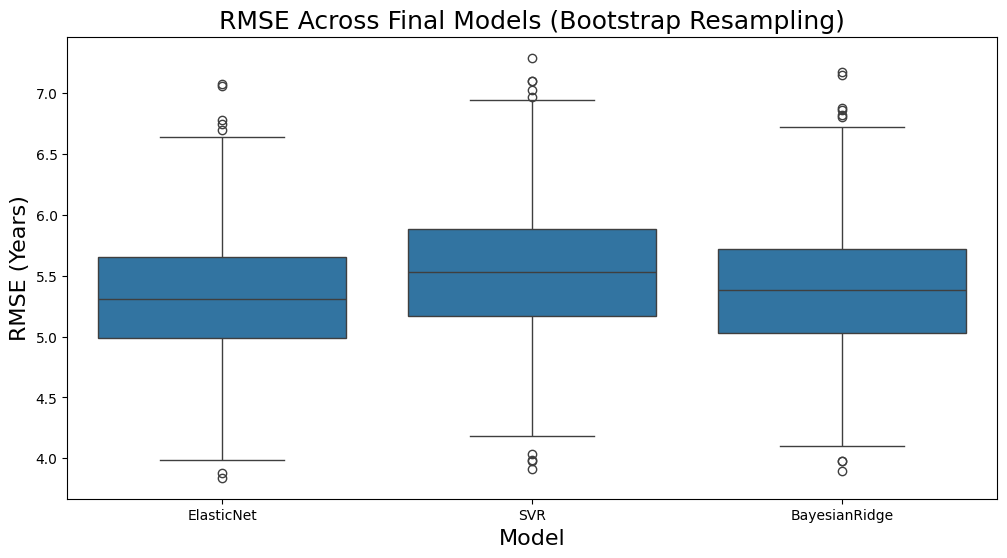

In [ ]:
#Compare the 3 models 
os.makedirs('../figures/Task4_Figures', exist_ok=True)

evaluation_results = pd.concat([
    final_models_stats['ElasticNet'].assign(Model='ElasticNet'),
    final_models_stats['SVR'].assign(Model='SVR'),
    final_models_stats['BayesianRidge'].assign(Model='BayesianRidge')])

#RMSE Boxplot for the final models 
plt.figure(figsize=(12,6))
sns.boxplot(data=evaluation_results, x='Model', y='RMSE')
plt.title('RMSE Across Final Models (Bootstrap Resampling)', fontsize=18)
plt.xlabel('Model', fontsize=16)
plt.ylabel('RMSE (Years)', fontsize=16)
plt.savefig('../figures/Task4_Figures/RMSE_final.png', dpi=300, bbox_inches='tight')
plt.show()

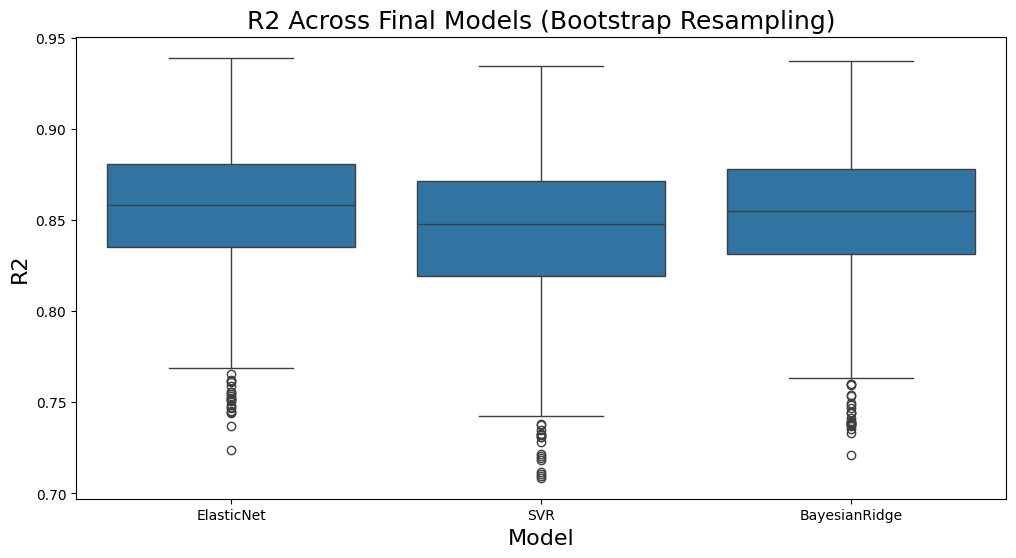

In [16]:
#Compare the 3 models 
#R2 Boxplot for the final models 
plt.figure(figsize=(12,6))
sns.boxplot(data=evaluation_results, x='Model', y='R2')
plt.title('R2 Across Final Models (Bootstrap Resampling)', fontsize=18)
plt.xlabel('Model', fontsize=16)
plt.ylabel('R2', fontsize=16)
plt.savefig('../figures/Task4_Figures/R2_final.png', dpi=300, bbox_inches='tight')
plt.show()

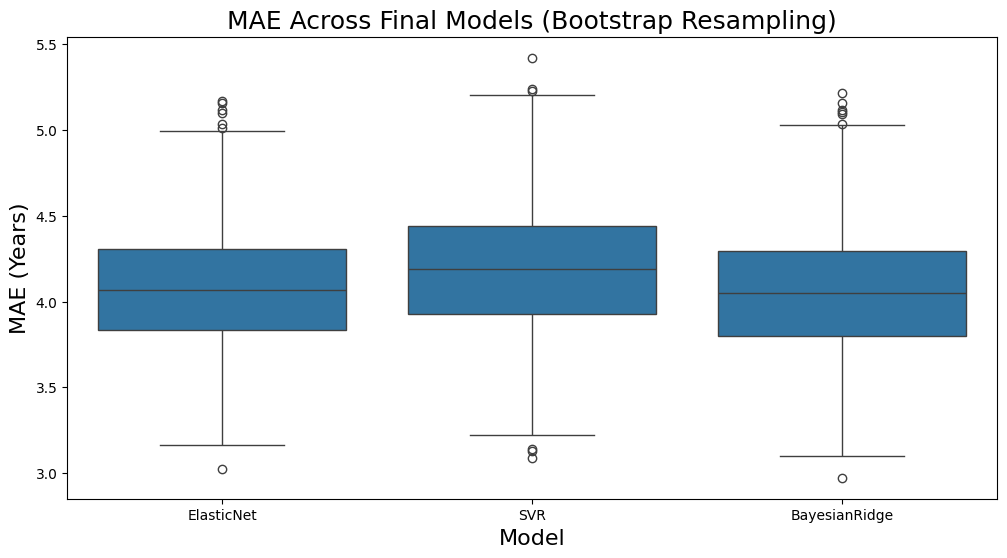

In [17]:
#Compare the 3 models 
#MAE Boxplot for the final models 
plt.figure(figsize=(12,6))
sns.boxplot(data=evaluation_results, x='Model', y='MAE')
plt.title('MAE Across Final Models (Bootstrap Resampling)', fontsize=18)
plt.xlabel('Model', fontsize=16)
plt.ylabel('MAE (Years)', fontsize=16)
plt.savefig('../figures/Task4_Figures/MAE_final.png', dpi=300, bbox_inches='tight')
plt.show()

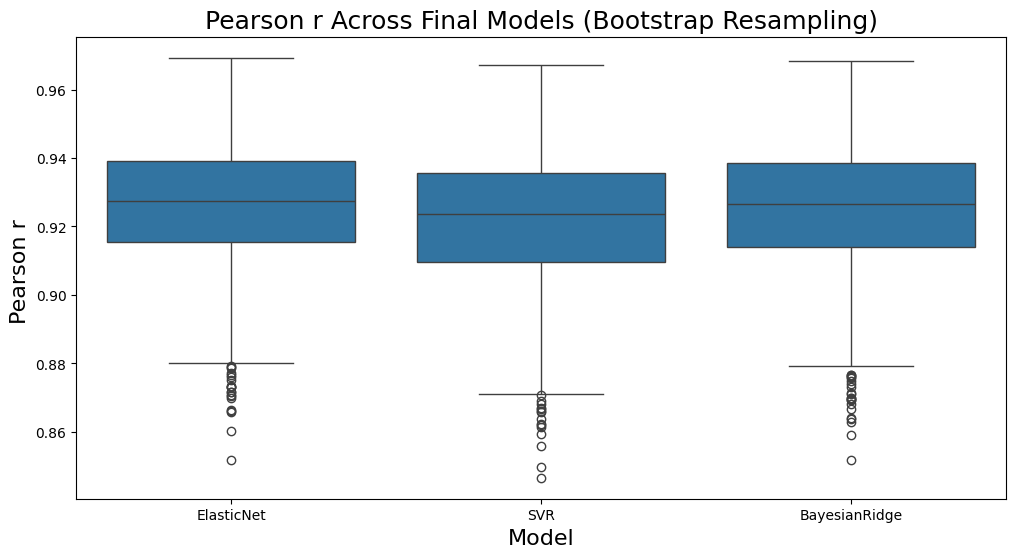

In [19]:
#Compare the 3 models 
#Pearson r Boxplot for the final models 
plt.figure(figsize=(12,6))
sns.boxplot(data=evaluation_results, x='Model', y='Pearson_r')
plt.title('Pearson r Across Final Models (Bootstrap Resampling)', fontsize=18)
plt.xlabel('Model', fontsize=16)
plt.ylabel('Pearson r ', fontsize=16)
plt.savefig('../figures/Task4_Figures/pearsonr_final.png', dpi=300, bbox_inches='tight')
plt.show()

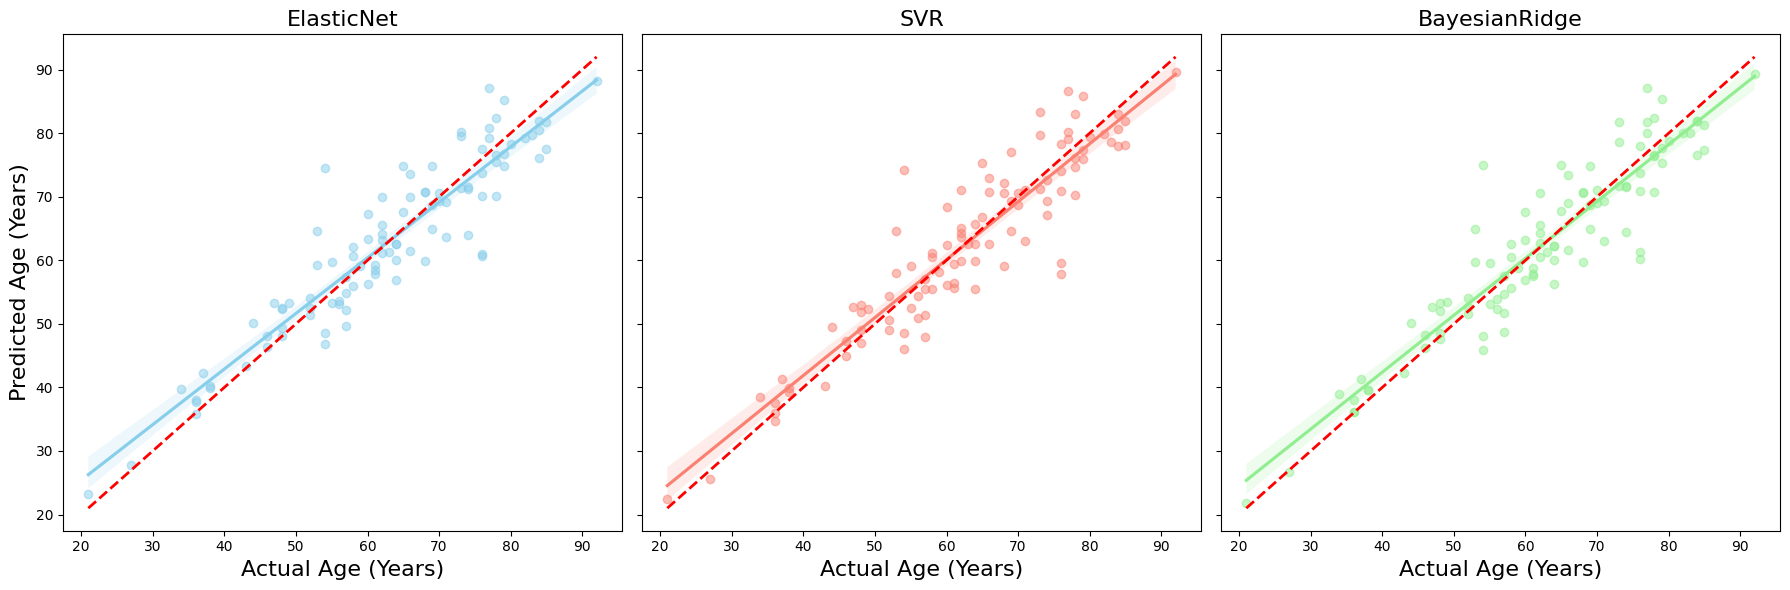

In [21]:
#Scatter plot of Predicted vs Actual Age for each tuned model on the evaluation set
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
models_preds = [
    (y_eval, final_elasticnet_pred, "ElasticNet", "skyblue"),
    (y_eval, final_svr_pred, "SVR", "salmon"),
    (y_eval, final_bayesianridge_pred, "BayesianRidge", "lightgreen")
]

for i, (y_true, y_pred, name, color) in enumerate(models_preds):
    sns.regplot(x=y_true, y=y_pred, ax=axes[i], color=color, scatter_kws={'alpha':0.5})
    axes[i].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[i].set_title(f'{name}', fontsize=16)
    axes[i].set_xlabel('Actual Age (Years)', fontsize=16)
    if i == 0: axes[i].set_ylabel('Predicted Age (Years)', fontsize=16)

plt.tight_layout()
plt.savefig('../figures/Task4_Figures/Actual_vs_Predicted_Age.png', dpi=300)
plt.show()

In [8]:
#Save best model 
os.makedirs('../models/Best_model', exist_ok=True)

joblib.dump(final_elasticnet, '../models/Best_model/best_model.joblib' )


['../models/Best_model/best_model.joblib']